In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')
from matplotlib.ticker import FuncFormatter, MaxNLocator
import duckdb

In [2]:
def query(query):
    return duckdb.sql(query).df()

In [3]:
sort_key = {
    'RWD': 1,
    'ARIMA': 0,
    'RA': 2,
    'PatchTST': 3,
    'Chronos-2': 4,
    'TiRex': 5,
    'Moirai-2.0': 6,
    'TimesFM': 7,
    'Toto': 8,
    'Sundial': 9
}

In [4]:
context_lengths = {
    "EdgeTraffic": {"FixedC": (900,), "FixedH": (120, 300, 600, 900, 1200, 1800, 2400)},
    "SPY": {"FixedC": (60,), "FixedH": (20, 40, 60, 126, 252, 378, 504)},
    "MixGridPL": {"FixedC": (240,), "FixedH": (96, 120, 168, 240, 336, 480, 600)},
}

horizon_lengths = {
    "EdgeTraffic": {"FixedC": (10, 60, 300, 600, 900, 1200, 1800), "FixedH": (60,)},
    "SPY": {"FixedC": (1, 5, 21, 42, 63, 126, 252), "FixedH": (5,)},
    "MixGridPL": {"FixedC": (12, 24, 72, 144, 288, 576, 672), "FixedH": (24,)},
}

In [5]:
def plot_results(dataset_name, sort_key, type_="FixedH"):

    def one_decimal_formatter(x, pos):
        if np.isclose(x, 0):
            return "0.0"
        if 0.1 <= abs(x) < 1000:
            return f"{x:.1f}"
        return f"{x:.1e}"

    def set_three_linear_ticks(ax):
        y0, y1 = ax.get_ylim()
        if np.isclose(y0, y1):
            y1 = y0 + 1
        ax.set_yticks(np.linspace(y0, y1, 4))
        ax.yaxis.set_major_formatter(FuncFormatter(one_decimal_formatter))

    def set_three_log_ticks(ax, values):
        vals = np.asarray(values, dtype=float)
        vals = vals[np.isfinite(vals) & (vals > 0)]

        if len(vals) == 0:
            return

        vmin = vals.min()
        vmax = vals.max()

        low_exp = int(np.floor(np.log10(vmin)))
        high_exp = int(np.ceil(np.log10(vmax)))

        start_exp = min(low_exp, high_exp - 3)
        ticks = 10.0 ** np.arange(start_exp, start_exp + 4)

        ymin = 0.0
        ymax = max(ticks[-1], vmax * 1.05)

        ax.set_yscale("log")
        ax.set_ylim(ymin, ymax)
        ax.set_yticks(ticks)
        ax.yaxis.set_major_formatter(FuncFormatter(one_decimal_formatter))

    if type_=="FixedH":
        t = horizon_lengths[dataset_name][f"{type_}"][0]
        title = f"{dataset_name} - Horizon={t}"
        t = "Context"
        column = "context_length"
    else:
        t = context_lengths[dataset_name][f"{type_}"][0]
        title = f"{dataset_name} - Context={t}"
        t = "Horizon"
        column = "horizon_length"


    fig, axes = plt.subplots(
        4, 1,
        figsize=(7, 6),
        sharex=True,
        gridspec_kw={"hspace": 0.12}
    )

    def prepare_pivot(sql, value_col, aggfunc="mean"):
        temp = query(sql).copy()
        temp.loc[temp["model_name"] == "RunningAverage", "model_name"] = "RA"

        pivot = temp.pivot_table(
            index="model_name",
            columns=column,
            values=value_col,
            aggfunc=aggfunc
        )

        pivot = pivot.loc[
            sorted(temp["model_name"].unique(), key=lambda x: sort_key[x])
        ].round(2)

        return pivot

    # ICE
    pivot_ice = prepare_pivot(
        f"""
        SELECT model_name, {column}, interval_violation
        FROM 'forecast_results.parquet'
        WHERE dataset_name='{dataset_name}'
          AND data_scenario='{type_}'
        """,
        value_col="interval_violation",
        aggfunc=lambda x: np.abs(np.mean(x) - 0.2)
    )
    pivot_ice.plot.bar(ax=axes[0], legend=True)
    axes[0].set_ylabel("ICE")
    # axes[0].set_ylim(0, 1.2)
    axes[0].set_title(title, pad=28)

    axes[0].legend(
        title=t,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=len(pivot_ice.columns),
        frameon=True,
        fontsize=8,
        title_fontsize=8,
        borderaxespad=0.0
    )

    fig.subplots_adjust(top=0.88)
    # SMAPE
    pivot_smape = prepare_pivot(
        f"""
        SELECT model_name, {column}, sape
        FROM 'forecast_results.parquet'
        WHERE dataset_name='{dataset_name}'
          AND data_scenario='{type_}'
        """,
        value_col="sape"
    )
    pivot_smape.plot.bar(ax=axes[1], legend=False)
    axes[1].set_ylabel("SMAPE")
    # axes[1].set_ylim(0, 140)

    # IMAE
    pivot_iae = prepare_pivot(
        f"""
        SELECT model_name, {column}, interval_absolute_error
        FROM 'forecast_results.parquet'
        WHERE dataset_name='{dataset_name}'
          AND data_scenario='{type_}'
        """,
        value_col="interval_absolute_error"
    )
    pivot_iae.plot.bar(ax=axes[2], legend=False)
    axes[2].set_ylabel("IMAE")
    # axes[2].set_ylim(0, 7.5)

    # Inference time
    temp = query(
        f"""
        SELECT model_name, {column}, fit_wall_time, predict_wall_time
        FROM 'forecast_results.parquet'
        WHERE dataset_name='{dataset_name}'
          AND data_scenario='{type_}'
        """
    ).copy().fillna(0)

    temp.loc[temp["model_name"] == "RunningAverage", "model_name"] = "RA"
    temp["total_wall_time"] = temp["fit_wall_time"] + temp["predict_wall_time"]

    pivot_time = temp.pivot_table(
        index="model_name",
        columns=column,
        values="total_wall_time"
    ).loc[
        sorted(temp["model_name"].unique(), key=lambda x: sort_key[x])
    ].round(2)

    pivot_time.plot.bar(ax=axes[3], legend=False, logy=True)
    axes[3].set_ylabel("Inference Time (s)")
    # axes[3].set_ylim(0.01, 180)
    axes[3].set_xlabel("Model")

    # Common styling
    for i, ax in enumerate(axes):
        ax.tick_params(
            axis="both",
            which="both",
            bottom=True,
            top=False,
            left=True,
            right=True,
            direction="in"
        )
        ax.grid(False)

        if i < 3:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        for tick in ax.get_xticklabels():
            tick.set_rotation(45)

    set_three_linear_ticks(axes[0])
    set_three_linear_ticks(axes[1])
    set_three_linear_ticks(axes[2])
    def compact_fmt(x, pos):
        if x >= 1000:
            return f"{x/1000:.1f}k"
        elif x >= 1:
            return f"{x:.1f}"
        else:
            return f"{x:.2f}"

    axes[2].yaxis.set_major_formatter(FuncFormatter(compact_fmt))

    set_three_log_ticks(axes[3], pivot_time.values)


    axes[3].yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x:.2f}" if x < 1 else f"{x:.1f}")
    )

    plt.tight_layout()
    plt.show()

/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin, ymax)
/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


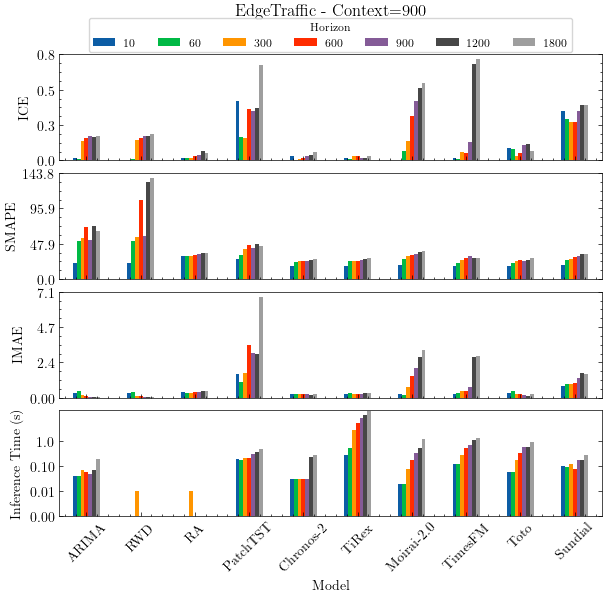

In [6]:
edge_traffic_fixedc_tables = plot_results("EdgeTraffic", sort_key=sort_key, type_="FixedC")

/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin, ymax)
/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


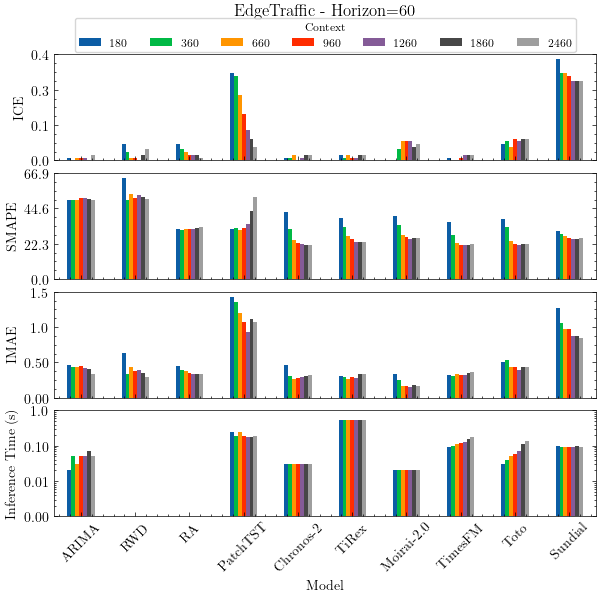

In [7]:
edge_traffic_fixedh_tables = plot_results("EdgeTraffic", sort_key=sort_key, type_="FixedH")

/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin, ymax)
/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


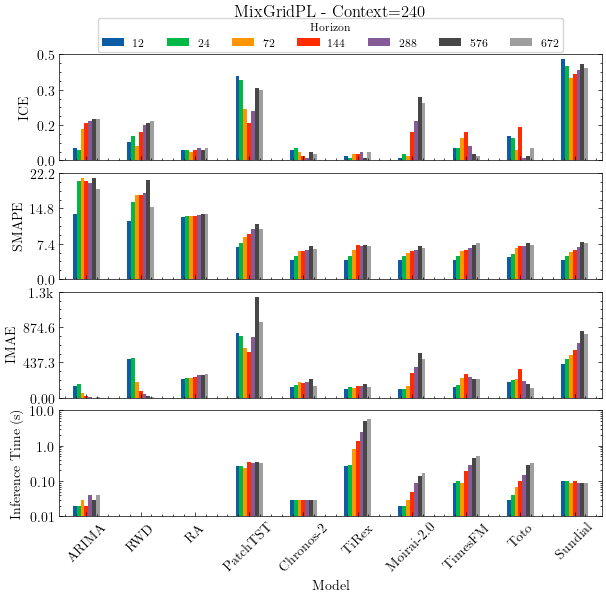

In [8]:
mix_grid_pl_fixedc_tables = plot_results("MixGridPL", sort_key=sort_key, type_="FixedC")

/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin, ymax)
/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


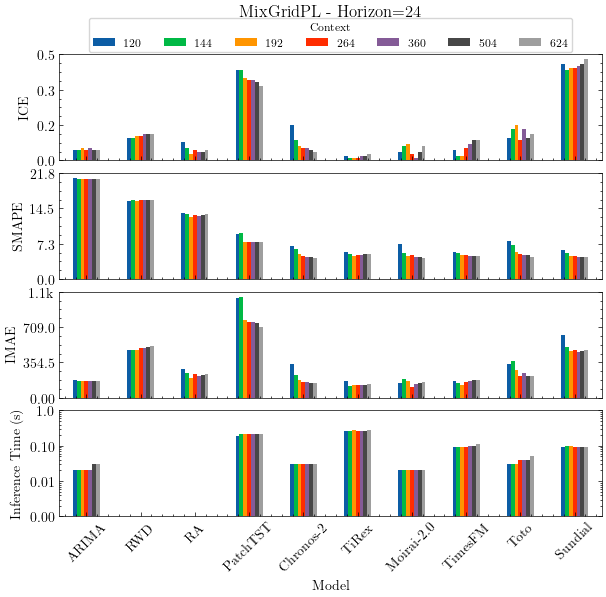

In [9]:
mix_grid_pl_fixedh_tables = plot_results("MixGridPL", sort_key=sort_key, type_="FixedH")

/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin, ymax)
/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


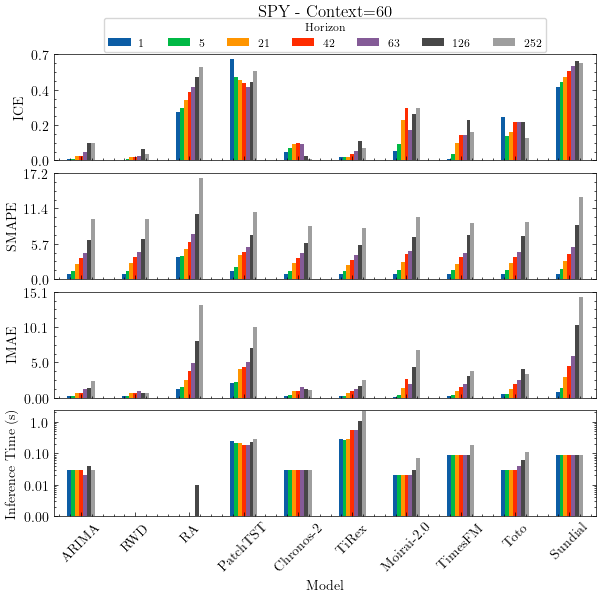

In [10]:
spy_fixedc_tables = plot_results("SPY", sort_key=sort_key, type_="FixedC")

/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin, ymax)
/var/folders/vh/vxs8kvnd5s351lv4syktqpdh0000gn/T/ipykernel_3107/3163359525.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


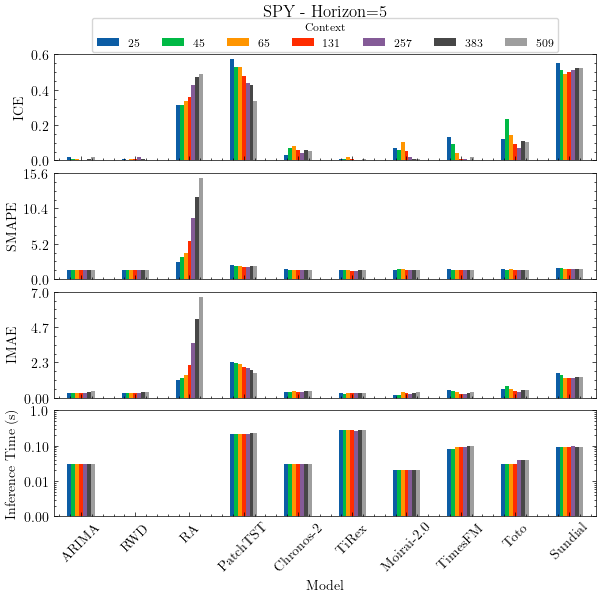

In [11]:
spy_fixedh_tables = plot_results("SPY", sort_key=sort_key, type_="FixedH")